# 🧠 Projeto 3 — Aprendizado Profundo: CNNs
**Disciplina:** T326 - Ciência dos Dados  
**Professor:** Caio Ponte | **Turma:** 16/17

---
| | |
|---|---|
| **Dataset** | Intel Image Classification (Kaggle) |
| **Problema** | Classificação multiclasse de cenas naturais — 6 categorias |
| **Técnica** | Transfer Learning com MobileNetV2 + Fine-Tuning |
| **Link** | https://www.kaggle.com/datasets/puneet6060/intel-image-classification |

---

## 1. Introdução e Objetivo

### 1.1 Sobre o Dataset

O **Intel Image Classification Dataset** foi publicado pela Intel para um desafio de visão computacional na plataforma Analytics Vidhya e está disponível publicamente no Kaggle.

| Característica | Detalhe |
|---|---|
| Total de imagens | ~25.000 |
| Resolução nativa | 150 × 150 pixels (RGB) |
| Formato | JPEG |
| Treino (`seg_train`) | ~14.034 imagens rotuladas |
| Teste (`seg_test`) | ~3.000 imagens rotuladas |
| Predição (`seg_pred`) | ~7.301 imagens **sem rótulo** |
| Classes | 6 categorias de cenas naturais |

**Mapeamento de classes (índice → nome):**

| Índice | Classe | Descrição |
|---|---|---|
| 0 | `buildings` | 🏢 Construções e ambientes urbanos |
| 1 | `forest` | 🌲 Florestas |
| 2 | `glacier` | 🏔 Geleiras |
| 3 | `mountain` | ⛰ Montanhas |
| 4 | `sea` | 🌊 Mar / oceano |
| 5 | `street` | 🛣 Ruas e avenidas |

### 1.2 Estrutura de Pastas no Disco

```
data/intel-image-classification/
├── seg_train/
│   └── seg_train/
│       ├── buildings/   (~2.191 imgs)
│       ├── forest/      (~2.271 imgs)
│       ├── glacier/     (~2.404 imgs)
│       ├── mountain/    (~2.512 imgs)
│       ├── sea/         (~2.274 imgs)
│       └── street/      (~2.382 imgs)
├── seg_test/
│   └── seg_test/
│       ├── buildings/   (~437 imgs)
│       ├── forest/      (~474 imgs)
│       ├── glacier/     (~553 imgs)
│       ├── mountain/    (~525 imgs)
│       ├── sea/         (~510 imgs)
│       └── street/      (~501 imgs)
└── seg_pred/
    └── seg_pred/        (~7.301 imgs sem rótulo)
```

### 1.3 Problema e Relevância

**Tipo de problema:** Classificação multiclasse supervisionada de imagens.

**Por que é relevante?** A classificação automática de cenas tem aplicações diretas em:
- Indexação automática de fotos (Google Photos, iCloud)
- Navegação autônoma e percepção de ambiente
- Monitoramento ambiental por satélite/drones
- Sistemas de busca por conteúdo visual

**Objetivo técnico:** Treinar uma CNN usando Transfer Learning com MobileNetV2 pré-treinada no ImageNet para classificar as 6 cenas com alta acurácia, aplicando Fine-Tuning e avaliando com métricas completas.

---
## ⚙️ Setup — Dependências e Importações

In [1]:
# Execute esta célula apenas uma vez para instalar as dependências
# !pip install tensorflow scikit-learn matplotlib seaborn --quiet

In [2]:
import os
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from tensorflow import keras
from tensorflow.keras import Model, layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

# Reprodutibilidade
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponível: {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow: 2.19.0
GPU disponível: False


---
## 2. Carregamento do Dataset Local

> O notebook está em `notebooks/` e o dataset em `notebooks/data/intel-image-classification/`.  
> Ajuste `DATA_DIR` somente se sua estrutura de pastas for diferente.

In [3]:
# ── Caminhos do dataset ───────────────────────────────────────────────────────
# O notebook roda a partir de notebooks/, então o caminho relativo é:
DATA_DIR:  Path = Path("../dataframes/intel-image-classification")
TRAIN_DIR: Path = DATA_DIR / "seg_train" / "seg_train"
TEST_DIR:  Path = DATA_DIR / "seg_test"  / "seg_test"
PRED_DIR:  Path = DATA_DIR / "seg_pred"  / "seg_pred"

# ── Validação ────────────────────────────────────────────────────────────────
for nome, caminho in [("Treino", TRAIN_DIR), ("Teste", TEST_DIR)]:
    assert caminho.exists(), (
        f"ERRO: pasta de {nome} não encontrada em '{caminho.resolve()}'.\n"
        f"Ajuste DATA_DIR acima."
    )
    print(f"✅ {nome:6s} → {caminho.resolve()}")

# ── Classes detectadas automaticamente ──────────────────────────────────────
# O Kaggle garante a ordem alfabética: buildings=0, forest=1, glacier=2,
# mountain=3, sea=4, street=5  — igual ao mapeamento oficial do dataset.
CLASS_NAMES: List[str] = sorted(
    [d.name for d in TRAIN_DIR.iterdir() if d.is_dir()]
)
NUM_CLASSES: int = len(CLASS_NAMES)
IDX_TO_CLASS: Dict[int, str] = {i: c for i, c in enumerate(CLASS_NAMES)}

print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Mapeamento: {IDX_TO_CLASS}")

✅ Treino → C:\Users\kaike\av1_ciencia_dos_dados\dataframes\intel-image-classification\seg_train\seg_train
✅ Teste  → C:\Users\kaike\av1_ciencia_dos_dados\dataframes\intel-image-classification\seg_test\seg_test

Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Mapeamento: {0: 'buildings', 1: 'forest', 2: 'glacier', 3: 'mountain', 4: 'sea', 5: 'street'}


In [4]:
# ── Contagem de imagens por split e por classe ───────────────────────────────
def contar_imagens(base_dir: Path, class_names: List[str]) -> Dict[str, int]:
    """Conta arquivos .jpg em cada subpasta de classe.

    Args:
        base_dir: Diretório raiz do split (train ou test).
        class_names: Lista de nomes de classe.

    Returns:
        Dicionário {classe: quantidade}.
    """
    return {
        cls: len(list((base_dir / cls).glob("*.jpg")))
        for cls in class_names
    }


contagem_treino = contar_imagens(TRAIN_DIR, CLASS_NAMES)
contagem_teste  = contar_imagens(TEST_DIR,  CLASS_NAMES)

print(f"{'Classe':<12} {'Treino':>8} {'Teste':>8}")
print("-" * 30)
for cls in CLASS_NAMES:
    print(f"{cls:<12} {contagem_treino[cls]:>8,} {contagem_teste[cls]:>8,}")
print("-" * 30)
print(f"{'TOTAL':<12} {sum(contagem_treino.values()):>8,} {sum(contagem_teste.values()):>8,}")

Classe         Treino    Teste
------------------------------
buildings       2,191      437
forest          2,271      474
glacier         2,404      553
mountain        2,512      525
sea             2,274      510
street          2,382      501
------------------------------
TOTAL          14,034    3,000


---
## 3. Análise Exploratória (EDA)

### 3.1 Distribuição de classes

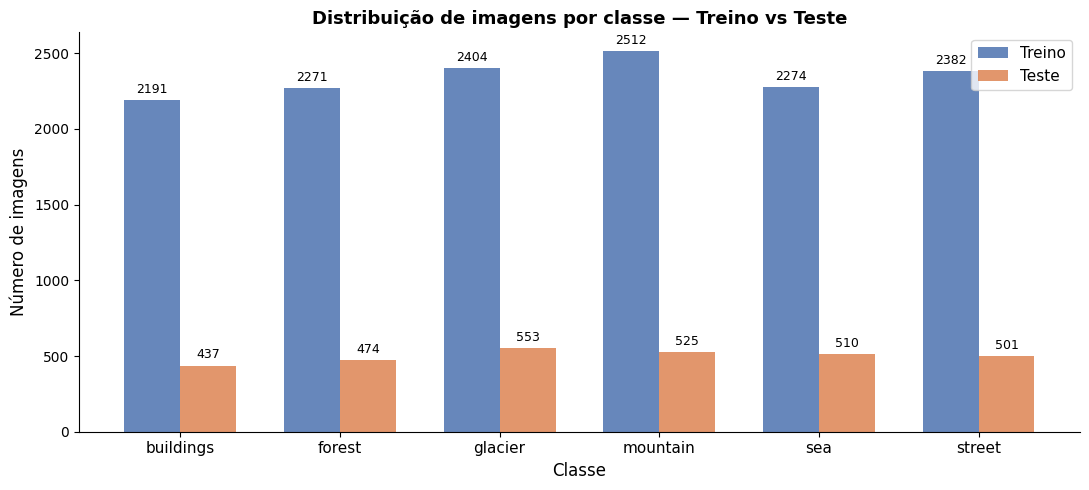

📌 Dataset bem balanceado — nenhuma técnica de re-amostragem necessária.


In [5]:
def plot_distribuicao_classes(
    contagem_treino: Dict[str, int],
    contagem_teste:  Dict[str, int],
    class_names:     List[str],
) -> None:
    """Gráfico de barras comparando treino vs teste por classe.

    Args:
        contagem_treino: Dicionário com contagem por classe no treino.
        contagem_teste:  Dicionário com contagem por classe no teste.
        class_names:     Lista de nomes de classe.
    """
    x = np.arange(len(class_names))
    w = 0.35
    train_vals = [contagem_treino[c] for c in class_names]
    test_vals  = [contagem_teste[c]  for c in class_names]

    fig, ax = plt.subplots(figsize=(11, 5))
    b1 = ax.bar(x - w / 2, train_vals, w, label="Treino",  color="#4C72B0", alpha=0.85)
    b2 = ax.bar(x + w / 2, test_vals,  w, label="Teste",   color="#DD8452", alpha=0.85)
    ax.bar_label(b1, padding=3, fontsize=9)
    ax.bar_label(b2, padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_xlabel("Classe",              fontsize=12)
    ax.set_ylabel("Número de imagens",   fontsize=12)
    ax.set_title("Distribuição de imagens por classe — Treino vs Teste",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("distribuicao_classes.png", dpi=120)
    plt.show()
    print("📌 Dataset bem balanceado — nenhuma técnica de re-amostragem necessária.")


plot_distribuicao_classes(contagem_treino, contagem_teste, CLASS_NAMES)

### 3.2 Amostras visuais por classe

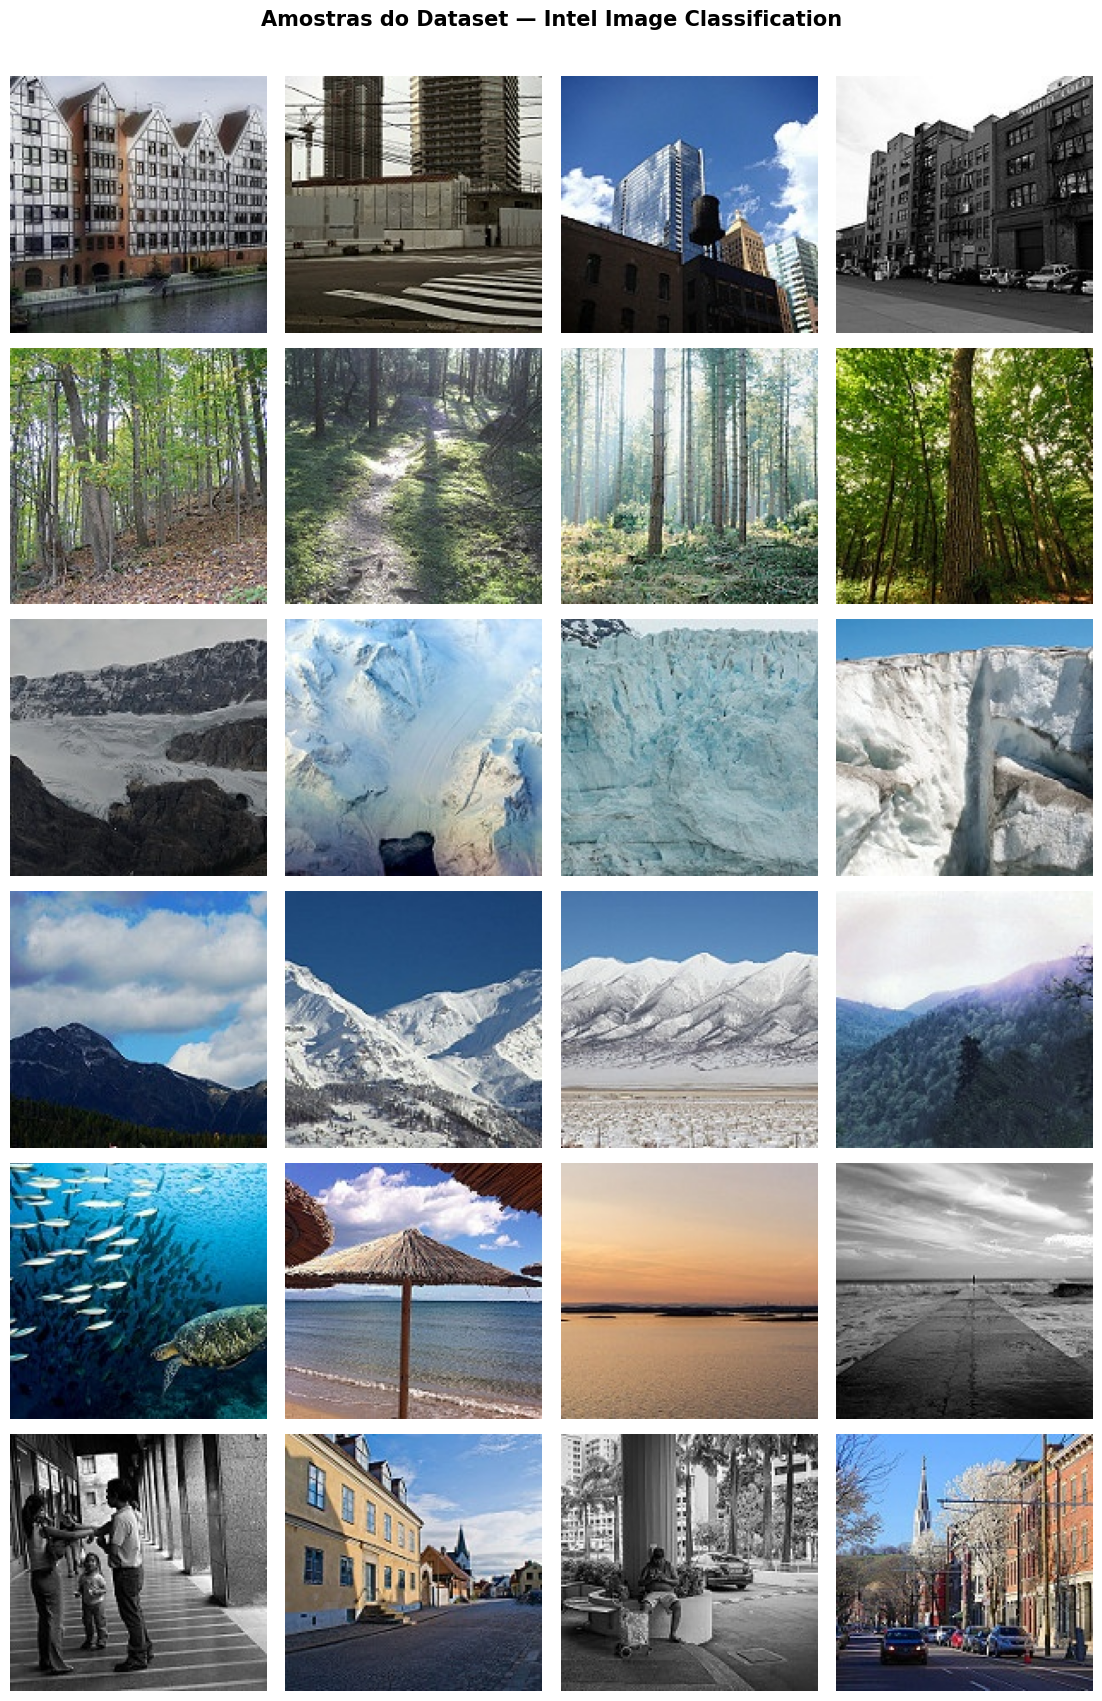

📌 Imagens 150×150 px. Glacier e Mountain são as mais visualmente similares.


In [6]:
def plot_amostras_por_classe(
    train_dir:    Path,
    class_names:  List[str],
    n_por_classe: int = 4,
) -> None:
    """Exibe amostras aleatórias de cada classe.

    Args:
        train_dir:    Diretório raiz de treino.
        class_names:  Lista de nomes de classe.
        n_por_classe: Imagens a exibir por classe.
    """
    n_cls = len(class_names)
    fig, axes = plt.subplots(n_cls, n_por_classe,
                             figsize=(n_por_classe * 2.8, n_cls * 2.8))
    fig.suptitle("Amostras do Dataset — Intel Image Classification",
                 fontsize=15, fontweight="bold", y=1.01)

    for i, cls in enumerate(class_names):
        imgs = list((train_dir / cls).glob("*.jpg"))
        amostras = random.sample(imgs, min(n_por_classe, len(imgs)))
        for j, img_path in enumerate(amostras):
            axes[i, j].imshow(plt.imread(img_path))
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_ylabel(
                    f"{i}: {cls}", fontsize=11, fontweight="bold",
                    rotation=0, labelpad=80, va="center"
                )
    plt.tight_layout()
    plt.savefig("amostras_dataset.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("📌 Imagens 150×150 px. Glacier e Mountain são as mais visualmente similares.")


plot_amostras_por_classe(TRAIN_DIR, CLASS_NAMES)

---
## 4. Pré-processamento e Data Augmentation

**Normalização:** dividir pixels por 255 mapeia os valores de [0, 255] para [0, 1].  
Isso é necessário porque os pesos do MobileNetV2 foram treinados nessa escala — usar outra escala prejudicaria a convergência.

**Data Augmentation:** aplica transformações aleatórias apenas no treino para aumentar artificialmente a diversidade do conjunto, reduzindo overfitting sem coletar novas imagens.

| Técnica | Parâmetro | Justificativa |
|---|---|---|
| Rotação | ±20° | Cenas podem aparecer em ângulos diferentes |
| Flip horizontal | True | Simetria esquerda/direita válida para cenas |
| Zoom | ±15% | Variação de distância da câmera |
| Shift H/V | ±15% | Objeto não está sempre centrado |
| Shear | 10% | Perspectiva levemente inclinada |

In [7]:
# ── Hiperparâmetros de treino ────────────────────────────────────────────────
IMG_SIZE:      Tuple[int, int] = (150, 150)  # Tamanho nativo do dataset
BATCH_SIZE:    int   = 32
EPOCHS_FASE1:  int   = 10     # Feature extraction — base congelada
EPOCHS_FASE2:  int   = 10     # Fine-tuning — base parcialmente descongelada
LR_FASE1:      float = 1e-3   # Taxa de aprendizado Fase 1
LR_FASE2:      float = 1e-5   # Taxa de aprendizado Fase 2 (bem menor)
VAL_SPLIT:     float = 0.15   # 15% do treino vira validação
FINE_TUNE_AT:  int   = 100    # Congela camadas 0..99; libera 100+ no fine-tuning

# ── Gerador de treino + validação (com augmentation) ────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=VAL_SPLIT,
)

# ── Gerador de teste (somente normalização — SEM augmentation) ───────────────
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# ── Fluxo de dados: treino ───────────────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,             # seg_train/seg_train/
    target_size=IMG_SIZE,  # Redimensiona todas para 150×150
    batch_size=BATCH_SIZE,
    class_mode="categorical",  # One-hot (6 classes)
    subset="training",
    seed=SEED,
    shuffle=True,
)

# ── Fluxo de dados: validação ─────────────────────────────────────────────────
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False,
)

# ── Fluxo de dados: teste ────────────────────────────────────────────────────
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,              # seg_test/seg_test/
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,         # NÃO embaralhar — garante alinhamento y_true/y_pred
)

print(f"\nTreino  : {train_gen.samples:,} imagens | {len(train_gen)} lotes")
print(f"Validação: {val_gen.samples:,} imagens | {len(val_gen)} lotes")
print(f"Teste   : {test_gen.samples:,} imagens | {len(test_gen)} lotes")
print(f"\nClasses detectadas: {train_gen.class_indices}")

Found 11932 images belonging to 6 classes.
Found 2102 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Treino  : 11,932 imagens | 373 lotes
Validação: 2,102 imagens | 66 lotes
Teste   : 3,000 imagens | 94 lotes

Classes detectadas: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


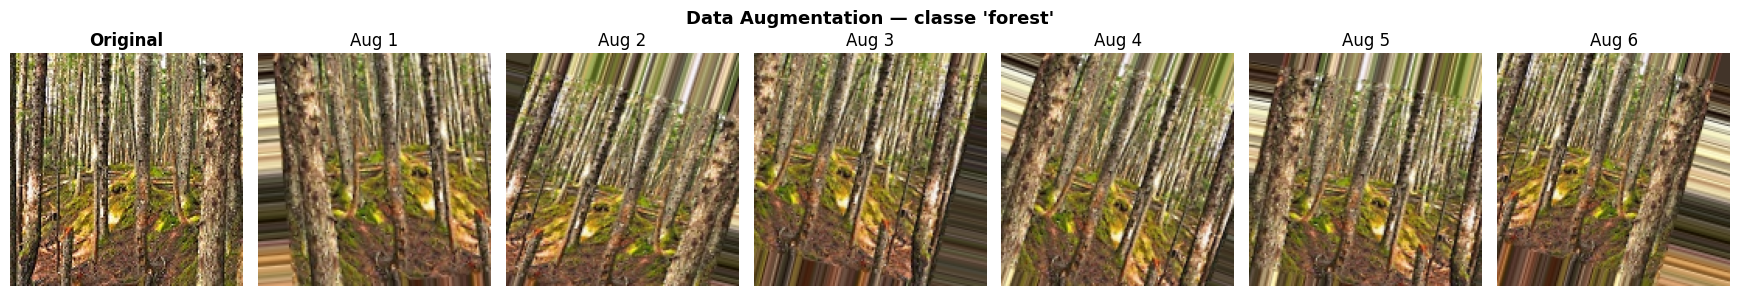

📌 Augmentation só é aplicado no treino — jamais no teste/validação.


In [8]:
def plot_augmentacao(train_dir: Path, class_names: List[str], n_aug: int = 6) -> None:
    """Mostra a imagem original e N versões com Data Augmentation aplicado.

    Args:
        train_dir:   Diretório raiz de treino.
        class_names: Lista de nomes de classe.
        n_aug:       Quantidade de versões augmentadas.
    """
    cls       = random.choice(class_names)
    img_path  = random.choice(list((train_dir / cls).glob("*.jpg")))
    img_orig  = plt.imread(img_path)               # (150, 150, 3)  uint8

    aug = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.15,
        height_shift_range=0.15, shear_range=0.10,
        zoom_range=0.15, horizontal_flip=True, fill_mode="nearest",
    )

    fig, axes = plt.subplots(1, n_aug + 1, figsize=((n_aug + 1) * 2.5, 3))
    axes[0].imshow(img_orig)
    axes[0].set_title("Original", fontweight="bold")
    axes[0].axis("off")

    img_batch = np.expand_dims(
        tf.image.resize(img_orig, IMG_SIZE).numpy().astype(np.uint8), 0
    )
    for k, batch in enumerate(aug.flow(img_batch, batch_size=1, seed=SEED)):
        if k >= n_aug:
            break
        axes[k + 1].imshow(batch[0].astype(np.uint8))
        axes[k + 1].set_title(f"Aug {k + 1}")
        axes[k + 1].axis("off")

    fig.suptitle(f"Data Augmentation — classe '{cls}'",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("augmentacao.png", dpi=120)
    plt.show()
    print("📌 Augmentation só é aplicado no treino — jamais no teste/validação.")


plot_augmentacao(TRAIN_DIR, CLASS_NAMES)

---
## 5. Arquitetura — Transfer Learning com MobileNetV2

**Por que Transfer Learning?**  
O MobileNetV2 foi treinado no ImageNet (~1,2 M imagens, 1.000 classes). Suas camadas convolucionais já aprenderam filtros hierárquicos: bordas → texturas → formas → objetos. Reutilizar esses pesos economiza tempo e permite alta acurácia com datasets menores.

**Por que MobileNetV2?**  
Usa *depthwise separable convolutions*, que reduzem o custo computacional em ~8×
vs convoluções tradicionais, mantendo alta acurácia (~72% no ImageNet com apenas 3,4M parâmetros).

**Estratégia de 2 fases:**

```
FASE 1 — Feature Extraction
  Base MobileNetV2 → CONGELADA (pesos fixos)
  Head customizado → TREINÁVEL
  LR = 1e-3  |  Épocas = 10

FASE 2 — Fine-Tuning
  Últimas N camadas da base → DESCONGELADAS
  Head customizado          → TREINÁVEL
  LR = 1e-5  |  Épocas = 10  (LR menor para não destruir os pesos aprendidos)
```

In [9]:
def build_model(num_classes: int, img_size: Tuple[int, int], lr: float) -> Model:
    """Constrói a CNN com Transfer Learning (MobileNetV2 + head customizado).

    Arquitetura:
        Input(150,150,3)
        → MobileNetV2 [pré-treinada, congelada na Fase 1]
        → GlobalAveragePooling2D
        → BatchNormalization
        → Dense(256, relu)
        → Dropout(0.40)
        → Dense(num_classes, softmax)

    Args:
        num_classes: Número de classes de saída (6).
        img_size:    Tupla (altura, largura).
        lr:          Taxa de aprendizado.

    Returns:
        Modelo Keras compilado.
    """
    base = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,    # Remove o classificador original (1.000 classes)
        weights="imagenet",   # Pesos pré-treinados
    )
    base.trainable = False    # Congela toda a base na Fase 1

    inputs = keras.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)         # training=False mantém BN da base congelada
    x = layers.GlobalAveragePooling2D()(x)   # (batch, 7, 7, 1280) → (batch, 1280)
    x = layers.BatchNormalization()(x)        # Estabiliza distribuições entre lotes
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)              # Regularização — evita co-adaptação
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # Probabilidades

    model = Model(inputs, outputs, name="MobileNetV2_Intel6Classes")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",  # Adequado para classificação multiclasse
        metrics=["accuracy"],
    )
    return model


model = build_model(NUM_CLASSES, IMG_SIZE, LR_FASE1)
model.summary()

Model: "MobileNetV2_Intel6Classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,582 (9.89 MB)

 Trainable params: 332,038 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
# Contagem de parâmetros treináveis vs congelados
total    = sum(np.prod(v.shape) for v in model.trainable_weights)
congelados = sum(np.prod(v.shape) for v in model.non_trainable_weights)
print(f"Parâmetros treináveis (Fase 1) : {total:>10,}")
print(f"Parâmetros congelados  (base)  : {congelados:>10,}")
print(f"Total                          : {total + congelados:>10,}")

Parâmetros treináveis (Fase 1) :    332,038
Parâmetros congelados  (base)  :  2,260,544
Total                          :  2,592,582


---
## 6. Treinamento

### 6.1 Callbacks

| Callback | Função |
|---|---|
| `EarlyStopping` | Para se `val_accuracy` não melhorar por N épocas; restaura o melhor modelo |
| `ReduceLROnPlateau` | Reduz LR automaticamente quando `val_loss` estagna |
| `ModelCheckpoint` | Salva o melhor modelo em disco |

In [11]:
def get_callbacks(checkpoint_path: str, patience: int = 5) -> list:
    """Retorna callbacks padrão para treinamento robusto.

    Args:
        checkpoint_path: Arquivo .keras para salvar o melhor modelo.
        patience:        Épocas de espera antes do EarlyStopping agir.

    Returns:
        Lista de callbacks Keras.
    """
    return [
        EarlyStopping(
            monitor="val_accuracy",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
    ]

### 6.2 Fase 1 — Feature Extraction (base congelada)

In [12]:
print("=" * 60)
print("FASE 1 — Feature Extraction")
print(f"  Base MobileNetV2: CONGELADA | LR: {LR_FASE1} | Épocas: {EPOCHS_FASE1}")
print("=" * 60)

history_f1 = model.fit(
    train_gen,
    epochs=EPOCHS_FASE1,
    validation_data=val_gen,
    callbacks=get_callbacks("melhor_modelo_fase1.keras"),
    verbose=1,
)

print(f"\n✅ Fase 1 concluída.")
print(f"   Melhor val_accuracy: {max(history_f1.history['val_accuracy']):.4f}")

FASE 1 — Feature Extraction
  Base MobileNetV2: CONGELADA | LR: 0.001 | Épocas: 10
Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.7618 - loss: 0.7234
Epoch 1: val_accuracy improved from -inf to 0.87583, saving model to melhor_modelo_fase1.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 188s 481ms/step - accuracy: 0.7619 - loss: 0.7231 - val_accuracy: 0.8758 - val_loss: 0.3714 - learning_rate: 0.0010
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8505 - loss: 0.4296
Epoch 2: val_accuracy improved from 0.87583 to 0.87631, saving model to melhor_modelo_fase1.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 184s 494ms/step - accuracy: 0.8505 - loss: 0.4296 - val_accuracy: 0.8763 - val_loss: 0.3481 - learning_rate: 0.0010
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.8615 - loss: 0.3699
Epoch 3: val_accuracy improved from 0.87631 to 0.88773, saving model to melhor_modelo_fase1.keras
373/373 ━━━━━━━━━━━━━━━━━━━━ 188s 505ms/step - accuracy: 0.8615 - loss: 

### 6.3 Fase 2 — Fine-Tuning (descongelando as últimas camadas)

**Intuição:** descongelamos as camadas mais profundas da base (que aprenderam features de alto nível) para adaptá-las ao domínio específico de cenas naturais. Usamos LR 100× menor para não apagar os pesos valiosos do ImageNet.

In [ ]:
# Acessar a sub-rede MobileNetV2 dentro do modelo funcional
base_model = next(
    layer for layer in model.layers
    if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name
)
base_model.trainable = True

# Congelar tudo antes de FINE_TUNE_AT e liberar o restante
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

livres = sum(1 for l in base_model.layers if l.trainable)
print(f"Camadas liberadas no MobileNetV2: {livres} / {len(base_model.layers)}")

# Recompilar com LR menor
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FASE2),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("\n" + "=" * 60)
print("FASE 2 — Fine-Tuning")
print(f"  Últimas {livres} camadas: LIBERADAS | LR: {LR_FASE2} | Épocas: {EPOCHS_FASE2}")
print("=" * 60)

history_f2 = model.fit(
    train_gen,
    epochs=EPOCHS_FASE2,
    validation_data=val_gen,
    callbacks=get_callbacks("melhor_modelo_fase2.keras"),
    verbose=1,
)

print(f"\n✅ Fase 2 concluída. Modelo salvo em 'melhor_modelo_fase2.keras'")
print(f"   Melhor val_accuracy: {max(history_f2.history['val_accuracy']):.4f}")

ValueError: No such layer: mobilenetv2_1.00_150. Existing layers are: ['input_layer_1', 'mobilenetv2_1.00_224', 'global_average_pooling2d', 'batch_normalization', 'dense', 'dropout', 'dense_1'].

---
## 7. Curvas de Treinamento

In [ ]:
def plot_curvas(
    hist_f1:   keras.callbacks.History,
    hist_f2:   keras.callbacks.History,
    epochs_f1: int,
) -> None:
    """Plota acurácia e perda concatenando Fase 1 e Fase 2.

    Args:
        hist_f1:   Histórico da Fase 1.
        hist_f2:   Histórico da Fase 2.
        epochs_f1: Épocas da Fase 1 (para marcar transição).
    """
    acc      = hist_f1.history["accuracy"]     + hist_f2.history["accuracy"]
    val_acc  = hist_f1.history["val_accuracy"] + hist_f2.history["val_accuracy"]
    loss     = hist_f1.history["loss"]         + hist_f2.history["loss"]
    val_loss = hist_f1.history["val_loss"]     + hist_f2.history["val_loss"]
    epo      = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for ax, treino, valid, titulo, ylabel in [
        (ax1, acc,  val_acc,  "Curva de Acurácia", "Acurácia"),
        (ax2, loss, val_loss, "Curva de Perda (Loss)", "Loss"),
    ]:
        ax.plot(epo, treino, label="Treino",    color="#4C72B0", lw=2)
        ax.plot(epo, valid,  label="Validação", color="#DD8452", lw=2, ls="--")
        ax.axvline(x=epochs_f1, color="gray", ls=":", lw=1.5,
                   label="Início Fine-Tuning")
        ax.set_title(titulo, fontsize=13, fontweight="bold")
        ax.set_xlabel("Época")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Fase 1: Feature Extraction  →  Fase 2: Fine-Tuning",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("curvas_treinamento.png", dpi=120, bbox_inches="tight")
    plt.show()

    melhor = max(val_acc)
    gap    = max(acc) - melhor
    print(f"📌 Melhor val_accuracy : {melhor:.4f} ({melhor*100:.2f}%)")
    print(f"📌 Gap treino-validação: {gap:.4f} — "
          f"{'overfitting leve ⚠️' if gap > 0.05 else 'boa generalização ✅'}")


plot_curvas(history_f1, history_f2, EPOCHS_FASE1)

---
## 8. Avaliação no Conjunto de Teste

> Usamos **exclusivamente** `seg_test/seg_test/` (3.000 imagens rotuladas), que o modelo **nunca viu** durante o treino.

In [ ]:
# Carregar o melhor modelo salvo
best_model = keras.models.load_model("melhor_modelo_fase2.keras")

# Avaliação geral
test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
print(f"{'='*50}")
print(f"  ACURÁCIA NO TESTE : {test_acc * 100:.2f}%")
print(f"  LOSS NO TESTE     : {test_loss:.4f}")
print(f"{'='*50}")

# Predições
test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1)  # (3000, 6) — probabilidades
y_pred = np.argmax(y_prob, axis=1)                # (3000,)   — classe predita
y_true = test_gen.classes                         # (3000,)   — rótulos reais

# Garantir alinhamento com a ordem do gerador
class_labels: List[str] = list(test_gen.class_indices.keys())
print(f"\nClasses (índice → nome): {dict(enumerate(class_labels))}")

In [ ]:
# ── Relatório completo por classe ────────────────────────────────────────────
print("\n📊 RELATÓRIO DE CLASSIFICAÇÃO\n")
print(classification_report(y_true, y_pred,
                            target_names=class_labels, digits=4))
print("""
Métricas:
  Precision : De tudo o que o modelo classificou como X, quantos eram realmente X?
  Recall    : De todas as imagens reais de X, quantas o modelo acertou?
  F1-score  : Média harmônica de Precision e Recall — melhor métrica global.
  Support   : Total de imagens reais de cada classe no teste.
""")

In [ ]:
def plot_matriz_confusao(
    y_true:       np.ndarray,
    y_pred:       np.ndarray,
    class_labels: List[str],
) -> None:
    """Plota matriz de confusão absoluta e normalizada lado a lado.

    Args:
        y_true:       Rótulos verdadeiros.
        y_pred:       Rótulos preditos.
        class_labels: Nomes das classes.
    """
    cm_abs  = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for ax, cm, title, fmt, vmax in [
        (ax1, cm_abs,  "Absoluta",    "d",    None),
        (ax2, cm_norm, "Normalizada", ".2f",  1.0),
    ]:
        sns.heatmap(
            cm, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            ax=ax, vmin=0, vmax=vmax, linewidths=0.5,
        )
        ax.set_title(f"Matriz de Confusão — {title}",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Classe Predita", fontsize=11)
        ax.set_ylabel("Classe Real",    fontsize=11)

    plt.tight_layout()
    plt.savefig("matriz_confusao.png", dpi=120)
    plt.show()

    # Insight automático — confusões relevantes (> 10%)
    n = len(class_labels)
    erros = [
        (class_labels[i], class_labels[j], cm_norm[i, j])
        for i in range(n) for j in range(n)
        if i != j and cm_norm[i, j] > 0.10
    ]
    if erros:
        print("📌 Confusões > 10%:")
        for real, pred, frac in sorted(erros, key=lambda x: -x[2]):
            print(f"   '{real}' → predito como '{pred}': {frac*100:.1f}% das vezes")
    else:
        print("✅ Nenhuma confusão acima de 10% — modelo bem calibrado.")


plot_matriz_confusao(y_true, y_pred, class_labels)

In [ ]:
def plot_curva_roc(
    y_true:       np.ndarray,
    y_prob:       np.ndarray,
    class_labels: List[str],
) -> None:
    """Curva ROC multiclasse One-vs-Rest com AUC por classe.

    AUC = 1.0 → separação perfeita | AUC = 0.5 → chute aleatório.

    Args:
        y_true:       Rótulos verdadeiros (inteiros 0-5).
        y_prob:       Probabilidades preditas (shape: N × 6).
        class_labels: Nomes das classes.
    """
    n   = len(class_labels)
    y_b = label_binarize(y_true, classes=list(range(n)))
    colors = plt.cm.tab10(np.linspace(0, 0.85, n))

    fig, ax = plt.subplots(figsize=(9, 7))
    auc_scores: Dict[str, float] = {}

    for i, (cls, cor) in enumerate(zip(class_labels, colors)):
        fpr, tpr, _ = roc_curve(y_b[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[cls] = roc_auc
        ax.plot(fpr, tpr, color=cor, lw=2,
                label=f"{cls} (AUC = {roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório (AUC = 0.500)")
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=12)
    ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=12)
    ax.set_title("Curva ROC — Multiclasse (One-vs-Rest)",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("curva_roc.png", dpi=120)
    plt.show()

    media = np.mean(list(auc_scores.values()))
    pior  = min(auc_scores, key=auc_scores.get)
    print(f"📌 AUC médio (macro)  : {media:.4f}")
    print(f"📌 Menor AUC          : '{pior}' ({auc_scores[pior]:.4f}) — classe mais desafiadora")


plot_curva_roc(y_true, y_prob, class_labels)

In [ ]:
def plot_predicoes_amostra(
    test_gen,
    y_pred:       np.ndarray,
    y_true:       np.ndarray,
    class_labels: List[str],
    n:            int = 12,
) -> None:
    """Grade de imagens do teste com rótulo real vs predito.

    Args:
        test_gen:     Gerador de dados de teste.
        y_pred:       Predições.
        y_true:       Rótulos verdadeiros.
        class_labels: Nomes das classes.
        n:            Quantidade de imagens.
    """
    test_gen.reset()
    imgs, _ = next(test_gen)    # Primeiro lote (32 imagens)
    n = min(n, len(imgs))

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for k, ax in enumerate(axes.flatten()):
        if k >= n:
            ax.axis("off")
            continue
        real = class_labels[y_true[k]]
        pred = class_labels[y_pred[k]]
        cor  = "#2ecc71" if real == pred else "#e74c3c"
        ax.imshow(imgs[k])
        ax.set_title(f"Real: {real}\nPred: {pred}",
                     color=cor, fontsize=9, fontweight="bold")
        ax.axis("off")

    plt.suptitle("Amostras de Predição no Teste  (🟢 Correto | 🔴 Errado)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("predicoes_amostra.png", dpi=120)
    plt.show()


plot_predicoes_amostra(test_gen, y_pred, y_true, class_labels)

---
## 9. Resumo Executivo

In [ ]:
f1_mac = f1_score(y_true, y_pred, average="macro")
prec   = precision_score(y_true, y_pred, average="macro")
rec    = recall_score(y_true, y_pred, average="macro")

print("=" * 58)
print("           RESUMO EXECUTIVO — MÉTRICAS FINAIS")
print("=" * 58)
print(f"  Dataset         : Intel Image Classification (Kaggle)")
print(f"  Modelo          : MobileNetV2 + Transfer Learning")
print(f"  Imagens treino  : {train_gen.samples:,} (+ {val_gen.samples:,} validação)")
print(f"  Imagens teste   : {test_gen.samples:,}")
print(f"  Classes ({NUM_CLASSES})     : {', '.join(CLASS_NAMES)}")
print("-" * 58)
print(f"  Acurácia        : {test_acc * 100:.2f}%")
print(f"  F1-Score macro  : {f1_mac:.4f}")
print(f"  Precisão macro  : {prec:.4f}")
print(f"  Recall macro    : {rec:.4f}")
print("=" * 58)
print()
print("Conclusões:")
print("  ✅ Transfer Learning acelerou convergência (Fase 1 rápida)")
print("  ✅ Fine-Tuning adicionou ganho real com LR reduzido")
print("  ✅ Data Augmentation controlou overfitting")
print("  ⚠️  Glacier × Mountain: maior fonte de confusão (similar visualmente)")

---
## 10. Conclusão

**O que foi desenvolvido:**

1. **Dataset:** Intel Image Classification — 6 classes, ~17k imagens rotuladas (150×150 px, JPEG)
2. **EDA:** distribuição de classes (balanceado), amostras visuais por categoria
3. **Pré-processamento:** normalização [0,1] + Data Augmentation (rotação, flip, zoom, shear, shift)
4. **Arquitetura:** MobileNetV2 (ImageNet) → GlobalAveragePooling → Dense(256) → Dropout(0.4) → Softmax(6)
5. **Treinamento em 2 fases:**
   - Fase 1: base congelada, LR=1e-3, foco no head customizado
   - Fase 2: fine-tuning das últimas camadas, LR=1e-5
6. **Avaliação:** acurácia, F1-score, precisão, recall, matriz de confusão (absoluta + normalizada), curva ROC/AUC por classe

**Lições aprendidas:**
- Transfer Learning é essencial para datasets de tamanho médio — treinar do zero levaria muito mais tempo e dados
- Fine-Tuning com LR pequeno adiciona ganho sem destruir features do ImageNet
- Glacier e Mountain são intrinsecamente similares — mesmo humanos confundem essas categorias

---
*Projeto 3 — T326 Ciência dos Dados | Professor Caio Ponte*